# Clustering par position - feature engineering

Objectif : repartir proprement pour construire des clusters de joueurs **par position**.

Plan du notebook :

1. récupérer la table `player` depuis Neon ;
2. refaire une exploration simple des données ;
3. ne garder que les joueurs sans valeurs nulles sur les données utilisées ;
4. préparer des features agrégées et relatives ;
5. préparer les groupes par position pour le futur clustering.

On ne cherche pas encore à interpréter un modèle ici : on prépare une base plus saine.

## 1. Setup

In [62]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

PROJECT_ROOT = Path.cwd()
SCHEMA = "public"
RANDOM_STATE = 42
K_RANGE = range(2, 9)

## 2. Connexion Neon

In [63]:
def load_env_file(path: Path) -> dict[str, str]:
    values = {}

    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")

    return values


def sqlalchemy_url(url: str) -> str:
    if url.startswith("postgres://"):
        return url.replace("postgres://", "postgresql+psycopg2://", 1)

    if url.startswith("postgresql://"):
        return url.replace("postgresql://", "postgresql+psycopg2://", 1)

    return url


env_path = PROJECT_ROOT / ".env"
if not env_path.exists():
    raise FileNotFoundError("Fichier .env introuvable à la racine du projet.")

local_env = load_env_file(env_path)
DATABASE_URL = (
    os.environ.get("NEON_DATABASE_URL")
    or os.environ.get("DATABASE_URL")
    or os.environ.get("POSTGRES_URL")
    or local_env.get("NEON_DATABASE_URL")
    or local_env.get("DATABASE_URL")
    or local_env.get("POSTGRES_URL")
    or ""
)

if not DATABASE_URL:
    raise RuntimeError("Ajoute NEON_DATABASE_URL, DATABASE_URL ou POSTGRES_URL dans .env.")

engine = create_engine(sqlalchemy_url(DATABASE_URL), pool_pre_ping=True)
print("Connexion configuree")

Connexion configuree


## 3. Charger les joueurs

In [64]:
players_df = pd.read_sql(
    f'''
    SELECT *
    FROM "{SCHEMA}"."player"
    ''',
    engine,
)

print(players_df.shape)
display(players_df.head())

(6705, 101)


,player_id,player_name,full_name,sofifa_name,player_aliases,date_of_birth,nationality,height_cm,weight_kg,preferred_foot,observed_positions,positions,best_position,club_name,club_league_name,club_position,sofifa_id,has_sofifa_profile,lineup_rows,match_count,team_count,first_match_date,last_match_date,transfermarkt_market_value_eur,transfermarkt_highest_market_value_eur,best_overall,overall_rating,potential,sofifa_market_value_raw,sofifa_wage_raw,skill_moves,weak_foot,international_reputation,body_type,real_face,sofifa_release_clause_raw,acceleration_type,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,attack_position,vision,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,pos_ls_rating,pos_st_rating,pos_rs_rating,pos_lw_rating,pos_lf_rating,pos_cf_rating,pos_rf_rating,pos_rw_rating,pos_lam_rating,pos_cam_rating,pos_ram_rating,pos_lm_rating,pos_lcm_rating,pos_cm_rating,pos_rcm_rating,pos_rm_rating,pos_lwb_rating,pos_ldm_rating,pos_cdm_rating,pos_rdm_rating,pos_rwb_rating,pos_lb_rating,pos_lcb_rating,pos_cb_rating,pos_rcb_rating,pos_rb_rating,pos_gk_rating,player_specialities_json,roles_json,playstyles_json
0,889193,AZ Jackson,Aziel Christopher Jackson,Aziel Jackson,AZ Jackson,2001-10-25,United States,175.0,68.0,Right,Left Winger,"CAM,CM,ST",CAM,Jagiellonia Białystok,Ekstraklasa,SUB,262094.0,1,6,6,1,2025-09-24,2025-12-18,NaN,NaN,66.0,64.0,71.0,€1.2M,€3K,3.0,3.0,1.0,Normal (170-185),No,€1.9M,Explosive,52.0,58.0,35.0,65.0,56.0,74.0,40.0,30.0,58.0,65.0,80.0,78.0,86.0,53.0,82.0,64.0,57.0,36.0,58.0,45.0,49.0,30.0,60.0,62.0,56.0,64.0,29.0,40.0,32.0,6.0,12.0,8.0,14.0,6.0,60.0,60.0,60.0,65.0,63.0,63.0,63.0,65.0,64.0,64.0,64.0,63.0,57.0,57.0,57.0,63.0,49.0,48.0,48.0,48.0,49.0,47.0,42.0,42.0,42.0,47.0,14.0,[],"[{""focus"": ""Attack"", ""name"": ""Shadow striker +...",[]
1,1122196,Aaron Bibout,None,None,Aaron Bibout,2004-09-09,Cameroon,193.0,NaN,None,Centre-Forward,None,None,KRC Genk,None,None,NaN,0,15,15,1,2025-08-28,2026-03-19,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
2,434207,Aaron Connolly,Aaron Anthony Connolly,Aaron Connolly,Aaron Connolly,2000-01-28,Republic of Ireland,175.0,73.0,Right,"Centre-Forward,Left Winger","ST,LM,CAM,LW",ST,Leyton Orient,League One,CAM,237286.0,1,4,4,1,2021-09-19,2021-10-23,3500000.0,7000000.0,70.0,68.0,72.0,€1.7M,€2K,3.0,3.0,1.0,Normal (170-185),Yes,€3.1M,Controlled explosive,54.0,69.0,65.0,63.0,68.0,68.0,62.0,43.0,45.0,68.0,77.0,73.0,78.0,68.0,78.0,70.0,75.0,67.0,62.0,68.0,68.0,21.0,70.0,58.0,60.0,63.0,25.0,23.0,20.0,12.0,8.0,12.0,13.0,12.0,68.0,68.0,68.0,67.0,68.0,68.0,68.0,67.0,66.0,66.0,66.0,65.0,58.0,58.0,58.0,65.0,49.0,46.0,46.0,46.0,49.0,46.0,43.0,43.0,43.0,46.0,18.0,[],"[{""focus"": ""Attack Support Versatile"", ""name"":...",[]
3,92571,Aaron Cresswell,Aaron William Cresswell,Aaron Cresswell,Aaron Cresswell,1989-12-15,England,175.0,66.0,Left,"Left-Back,Centre-Back","LB,CB,LM",LB,Stoke City,Championship,LB,189615.0,1,97,97,1,2021-08-15,2025-05-18,450000.0,12000000.0,72.0,72.0,72.0,€725K,€18K,2.0,3.0,1.0,Normal (170-185),Yes,€1.4M,Controlled,79.0,53.0,70.0,75.0,48.0,70.0,78.0,74.0,67.0,74.0,52.0,48.0,63.0,72.0,65.0,70.0,74.0,56.0,63.0,66.0,73.0,74.0,60.0,68.0,59.0,71.0,75.0,76.0,75.0,14.0,7.0,9.0,9.0,12.0,64.0,64.0,64.0,66.0,66.0,66.0,66.0,66.0,67.0,67.0,67.0,67.0,69.0,69.0,69.0,67.0,70.0,72.0,72.0,72.0,70.0,70.0,72.0,72.0,72.0,70.0,17.0,[],"[{""focus"": ""Defend Balanced Versatile"", ""name""...",[]
4,591949,Aaron Hickey,Aaron Buchanan Hickey,Aaron Hickey,Aaron 

## 4. Définir les postes et les features utiles

On reprend le découpage pertinent de `cluster_players.ipynb` :

- les gardiens ont leur propre set de features ;
- les joueurs de champ ont un autre set de features ;
- le clustering restera préparé par `best_position`.

In [65]:
# Groupes de postes utilisés seulement pour choisir le bon set de features.
POSITION_GROUPS = {
    "Gardien": ["GK"],
    "Défenseur": ["CB", "LB", "RB", "LWB", "RWB"],
    "Milieu": ["CDM", "CM", "CAM", "LM", "RM"],
    "Attaquant": ["ST", "CF", "LW", "RW"],
}

position_to_group = {
    position: group
    for group, positions in POSITION_GROUPS.items()
    for position in positions
}

# Features joueurs de champ : attributs football + quelques infos de profil.
outfield_attributes = [
    "crossing", "finishing", "heading_accuracy", "short_passing", "volleys", "dribbling",
    "curve", "fk_accuracy", "long_passing", "ball_control", "acceleration", "sprint_speed",
    "agility", "reactions", "balance", "shot_power", "jumping", "stamina", "strength",
    "long_shots", "aggression", "interceptions", "attack_position", "vision", "penalties",
    "composure", "defensive_awareness", "standing_tackle", "sliding_tackle",
]

profile_attributes = ["skill_moves", "weak_foot", "height_cm", "weight_kg"]

# Features gardiens : attributs gardien + dimensions utiles de relance, mobilité et physique.
goalkeeper_attributes = ["gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"]

goalkeeper_style_attributes = [
    "reactions", "composure", "jumping", "strength", "stamina", "aggression",
    "height_cm", "weight_kg", "short_passing", "long_passing", "vision", "ball_control",
    "shot_power", "weak_foot", "acceleration", "sprint_speed", "agility", "balance",
]

field_attribute_set = outfield_attributes + profile_attributes
goalkeeper_attribute_set = goalkeeper_attributes + goalkeeper_style_attributes

attributes_by_position = {
    position: (goalkeeper_attribute_set if position == "GK" else field_attribute_set)
    for positions in POSITION_GROUPS.values()
    for position in positions
}

all_feature_columns = sorted(set(field_attribute_set + goalkeeper_attribute_set))
identity_columns = ["player_id", "best_position"]

missing_columns = [
    column
    for column in identity_columns + all_feature_columns
    if column not in players_df.columns
]

if missing_columns:
    raise KeyError(f"Colonnes absentes de players_df: {missing_columns}")

print("Features joueurs de champ:", len(field_attribute_set))
print("Features gardiens:", len(goalkeeper_attribute_set))
display(pd.DataFrame([
    {"feature_set": "field_attribute_set", "feature_count": len(field_attribute_set), "features": field_attribute_set},
    {"feature_set": "goalkeeper_attribute_set", "feature_count": len(goalkeeper_attribute_set), "features": goalkeeper_attribute_set},
]))

Features joueurs de champ: 33
Features gardiens: 23


,feature_set,feature_count,features
0,field_attribute_set,33,"[crossing, finishing, heading_accuracy, short_..."
1,goalkeeper_attribute_set,23,"[gk_diving, gk_handling, gk_kicking, gk_positi..."


## 5. Construire la base joueur

In [66]:
players_features_df = players_df[identity_columns + all_feature_columns].copy()
players_features_df["position_group"] = players_features_df["best_position"].map(position_to_group)

for column in all_feature_columns:
    players_features_df[column] = pd.to_numeric(players_features_df[column], errors="coerce")

# Nombre de valeurs manquantes uniquement sur les features réellement utiles au poste.
def count_missing_required_features(row):
    required_attributes = attributes_by_position.get(row["best_position"], [])

    if not required_attributes:
        return None

    return int(row[required_attributes].isna().sum())

players_features_df["required_feature_count"] = players_features_df["best_position"].map(
    lambda position: len(attributes_by_position.get(position, []))
)
players_features_df["missing_required_count"] = players_features_df.apply(
    count_missing_required_features,
    axis=1,
)

print(players_features_df.shape)
display(players_features_df.head())

(6705, 43)


,player_id,best_position,acceleration,aggression,agility,attack_position,balance,ball_control,composure,crossing,curve,defensive_awareness,dribbling,finishing,fk_accuracy,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,heading_accuracy,height_cm,interceptions,jumping,long_passing,long_shots,penalties,reactions,short_passing,shot_power,skill_moves,sliding_tackle,sprint_speed,stamina,standing_tackle,strength,vision,volleys,weak_foot,weight_kg,position_group,required_feature_count,missing_required_count
0,889193,CAM,80.0,49.0,86.0,60.0,82.0,65.0,64.0,52.0,40.0,29.0,74.0,58.0,30.0,6.0,12.0,8.0,14.0,6.0,35.0,175.0,30.0,57.0,58.0,45.0,56.0,53.0,65.0,64.0,3.0,32.0,78.0,36.0,40.0,58.0,62.0,56.0,3.0,68.0,Milieu,33,0.0
1,1122196,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,434207,ST,77.0,68.0,78.0,70.0,78.0,68.0,63.0,54.0,62.0,25.0,68.0,69.0,43.0,12.0,8.0,12.0,13.0,12.0,65.0,175.0,21.0,75.0,45.0,68.0,60.0,68.0,63.0,70.0,3.0,20.0,73.0,67.0,23.0,62.0,58.0,68.0,3.0,73.0,Attaquant,33,0.0
3,92571,LB,52.0,73.0,63.0,60.0,65.0,74.0,71.0,79.0,78.0,75.0,70.0,53.0,74.0,14.0,7.0,9.0,9.0,12.0,70.0,175.0,74.0,74.0,67.0,66.0,59.0,72.0,75.0,70.0,2.0,75.0,48.0,56.0,76.0,63.0,68.0,48.0,3.0,66.0,Défenseur,33,0.0
4,591949,RB,70.0,78.0,71.0,59.0,64.0,74.0,72.0,74.0,61.0,75.0,74.0,48.0,40.0,13.0,14.0,8.0,13.0,5.0,67.0,185.0,72.0,69.0,68.0,60.0,47.0,73.0,75.0,68.0,2.0,75.0,72.0,60.0,76.0,59.0,67.0,67.0,5.0,72.0,Défenseur,33,0.0


## 6. Exploration des valeurs nulles

In [67]:
missing_by_column_df = (
    players_features_df[all_feature_columns + ["best_position", "position_group"]]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_by_column_df.columns = ["column", "missing_count"]
missing_by_column_df["missing_rate"] = (
    missing_by_column_df["missing_count"] / len(players_features_df)
).round(3)

missing_by_row_df = (
    players_features_df[[
        "player_id",
        "best_position",
        "position_group",
        "required_feature_count",
        "missing_required_count",
    ]]
    .sort_values("missing_required_count", ascending=False, na_position="first")
)

position_counts_before_df = (
    players_features_df
    .groupby(["position_group", "best_position"], dropna=False)
    .size()
    .reset_index(name="player_count")
    .sort_values(["position_group", "player_count"], ascending=[True, False])
)

display(missing_by_column_df)
display(missing_by_row_df.head(20))
display(position_counts_before_df)

,column,missing_count,missing_rate
0,defensive_awareness,1683,0.251
1,composure,1665,0.248
2,acceleration,1659,0.247
3,sprint_speed,1659,0.247
4,long_shots,1659,0.247
5,penalties,1659,0.247
6,reactions,1659,0.247
7,short_passing,1659,0.247
8,shot_power,1659,0.247
9,skill_moves,1659,0.247


,player_id,best_position,position_group,required_feature_count,missing_required_count
1,1122196,None,NaN,0,NaN
5,974996,None,NaN,0,NaN
9,853239,None,NaN,0,NaN
10,1301102,None,NaN,0,NaN
11,9335,None,NaN,0,NaN
19,860062,None,NaN,0,NaN
20,1019170,None,NaN,0,NaN
21,1186467,None,NaN,0,NaN
27,1160184,None,NaN,0,NaN
30,689091,None,NaN,0,NaN


,position_group,best_position,player_count
3,Attaquant,ST,690
2,Attaquant,RW,79
1,Attaquant,LW,56
0,Attaquant,CF,24
4,Défenseur,CB,998
7,Défenseur,RB,243
5,Défenseur,LB,239
8,Défenseur,RWB,64
6,Défenseur,LWB,60
9,Gardien,GK,505


## 7. Filtrer les lignes complètes

In [68]:
# On garde uniquement les joueurs complets sur les features requises pour leur poste.
players_complete_df = (
    players_features_df[
        players_features_df["position_group"].notna()
        & players_features_df["missing_required_count"].eq(0)
    ]
    .drop_duplicates(subset="player_id")
    .reset_index(drop=True)
)

position_counts_after_df = (
    players_complete_df
    .groupby(["position_group", "best_position"], dropna=False)
    .size()
    .reset_index(name="player_count")
    .sort_values(["position_group", "player_count"], ascending=[True, False])
)

coverage_summary_df = pd.DataFrame([
    {"step": "initial", "players": len(players_features_df)},
    {"step": "complete_required_features", "players": len(players_complete_df)},
])
coverage_summary_df["coverage_rate"] = (
    coverage_summary_df["players"] / len(players_features_df)
).round(3)

display(coverage_summary_df)
display(position_counts_after_df)

,step,players,coverage_rate
0,initial,6705,1.000
1,complete_required_features,5023,0.749


,position_group,best_position,player_count
3,Attaquant,ST,688
2,Attaquant,RW,78
1,Attaquant,LW,55
0,Attaquant,CF,24
4,Défenseur,CB,995
7,Défenseur,RB,243
5,Défenseur,LB,236
8,Défenseur,RWB,63
6,Défenseur,LWB,60
9,Gardien,GK,505


## 8. Exploration des features complètes

,mean,std,min,25%,50%,75%,max,iqr
sliding_tackle,54.0,19.7,10.0,36.0,61.0,70.0,89.0,34.0
interceptions,55.7,19.6,11.0,38.0,63.0,71.0,91.0,33.0
standing_tackle,57.1,19.3,10.0,40.0,64.0,72.0,91.0,32.0
defensive_awareness,55.2,18.8,10.0,39.0,61.0,70.0,91.0,31.0
volleys,52.9,15.4,12.0,41.0,55.0,65.0,92.0,24.0
fk_accuracy,51.6,15.0,15.0,40.0,51.0,63.0,93.0,23.0
finishing,57.2,16.3,15.0,46.0,61.0,69.0,94.0,23.0
penalties,55.5,13.0,20.0,45.0,55.0,65.0,93.0,20.0
curve,59.8,14.5,20.0,51.0,62.0,71.0,93.0,20.0
long_shots,58.0,15.6,15.0,49.0,62.0,69.0,91.0,20.0


,mean,std,min,25%,50%,75%,max,iqr
composure,44.6,13.5,20.0,34.0,43.0,57.0,70.0,23.0
long_passing,33.1,12.5,11.0,23.0,30.0,42.0,68.0,19.0
balance,39.4,11.0,20.0,30.0,40.0,48.0,68.0,18.0
agility,40.9,11.4,21.0,32.0,39.0,50.0,70.0,18.0
vision,45.5,11.7,12.0,37.0,45.0,54.0,70.0,17.0
acceleration,38.5,11.3,15.0,30.0,39.0,47.0,65.0,17.0
sprint_speed,39.1,10.8,15.0,32.0,40.0,47.0,65.0,15.0
strength,62.9,9.8,30.0,56.0,64.0,70.0,83.0,14.0
short_passing,32.5,11.1,13.0,25.0,31.0,39.0,65.0,14.0
reactions,64.9,9.3,33.0,59.0,65.0,71.0,88.0,12.0


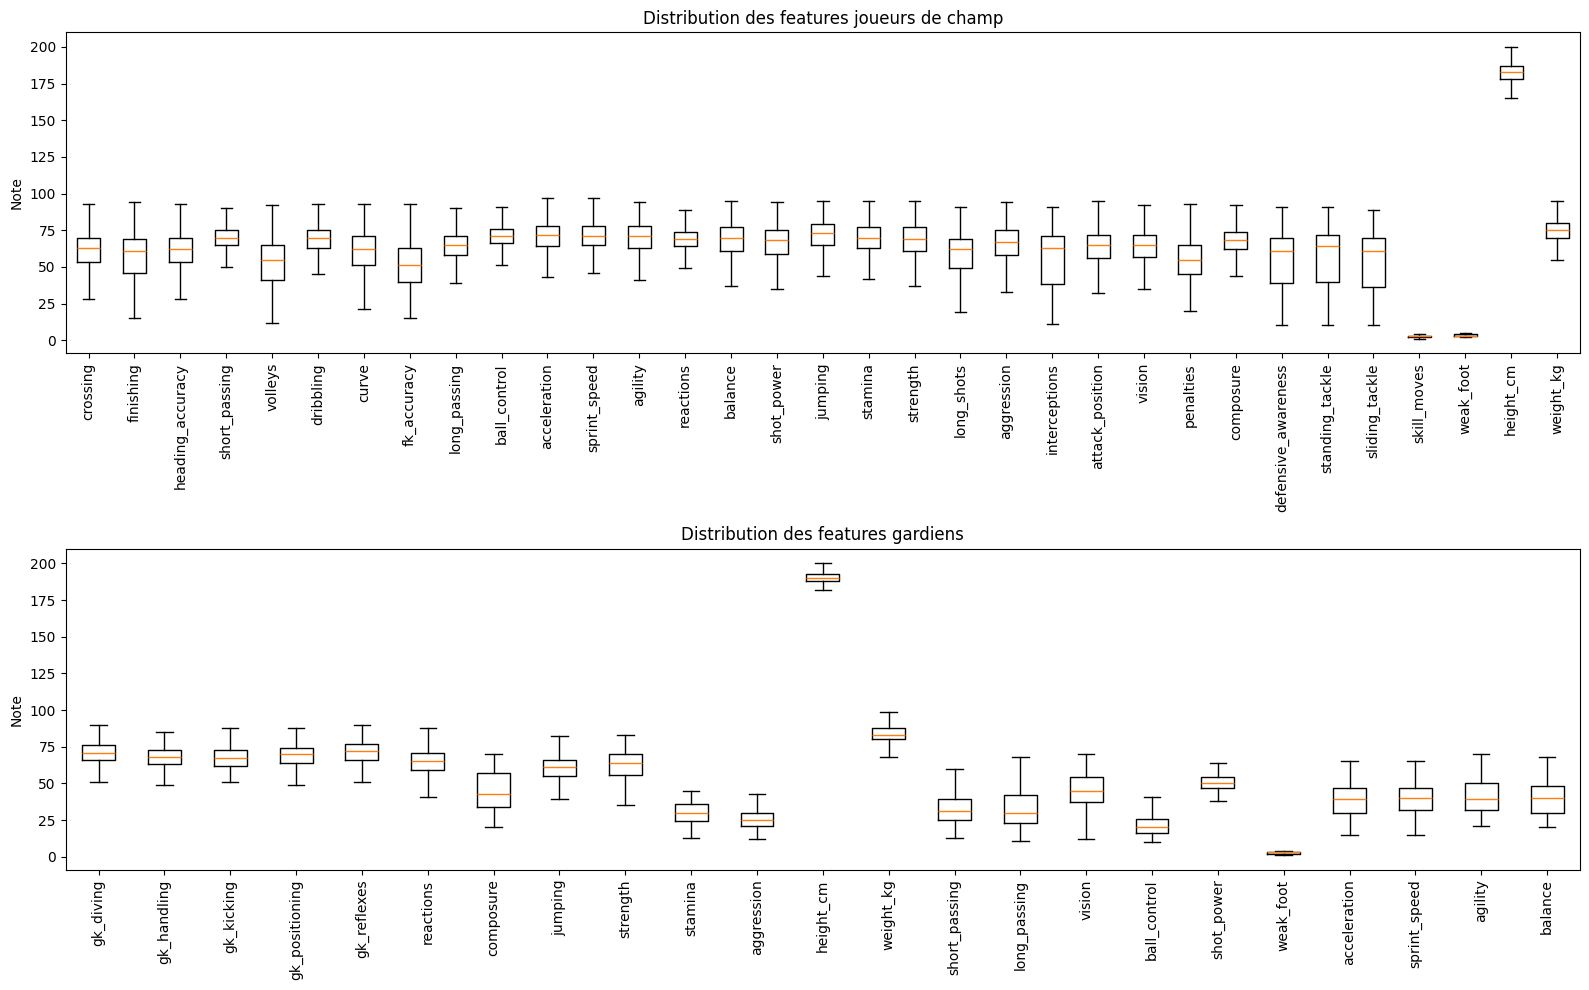

In [69]:
# Exploration séparée : joueurs de champ vs gardiens.
field_players_df = players_complete_df[players_complete_df["best_position"] != "GK"].copy()
goalkeepers_df = players_complete_df[players_complete_df["best_position"] == "GK"].copy()

field_feature_summary_df = (
    field_players_df[field_attribute_set]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(1)
)
field_feature_summary_df["iqr"] = (field_feature_summary_df["75%"] - field_feature_summary_df["25%"]).round(1)
field_feature_summary_df = field_feature_summary_df.sort_values("iqr", ascending=False)

gk_feature_summary_df = (
    goalkeepers_df[goalkeeper_attribute_set]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(1)
)
gk_feature_summary_df["iqr"] = (gk_feature_summary_df["75%"] - gk_feature_summary_df["25%"]).round(1)
gk_feature_summary_df = gk_feature_summary_df.sort_values("iqr", ascending=False)

display(field_feature_summary_df)
display(gk_feature_summary_df)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].boxplot([field_players_df[column].dropna() for column in field_attribute_set], showfliers=False)
axes[0].set_xticks(range(1, len(field_attribute_set) + 1))
axes[0].set_xticklabels(field_attribute_set, rotation=90)
axes[0].set_title("Distribution des features joueurs de champ")
axes[0].set_ylabel("Note")

axes[1].boxplot([goalkeepers_df[column].dropna() for column in goalkeeper_attribute_set], showfliers=False)
axes[1].set_xticks(range(1, len(goalkeeper_attribute_set) + 1))
axes[1].set_xticklabels(goalkeeper_attribute_set, rotation=90)
axes[1].set_title("Distribution des features gardiens")
axes[1].set_ylabel("Note")

plt.tight_layout()
plt.show()

## 9. Feature engineering : agrégats par type de poste

In [70]:
field_feature_groups = {
    "pace": ["sprint_speed", "acceleration"],
    "shooting": ["finishing", "attack_position", "shot_power", "long_shots", "penalties", "volleys"],
    "passing": ["vision", "crossing", "fk_accuracy", "long_passing", "short_passing", "curve"],
    "dribbling": ["agility", "balance", "reactions", "composure", "ball_control", "dribbling"],
    "defending": ["interceptions", "heading_accuracy", "defensive_awareness", "standing_tackle", "sliding_tackle"],
    "physical": ["jumping", "stamina", "strength", "aggression"],
}

gk_feature_groups = {
    "goalkeeping": ["gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"],
    "keeper_distribution": ["short_passing", "long_passing", "vision", "ball_control"],
    "keeper_mobility": ["acceleration", "sprint_speed", "agility", "balance", "reactions"],
    "keeper_physical": ["jumping", "strength", "stamina", "aggression"],
}

players_engineered_df = players_complete_df[["player_id", "best_position", "position_group"] + all_feature_columns].copy()

for group_name, columns in field_feature_groups.items():
    players_engineered_df[group_name] = players_engineered_df[columns].mean(axis=1).round(1)

for group_name, columns in gk_feature_groups.items():
    players_engineered_df[group_name] = players_engineered_df[columns].mean(axis=1).round(1)

field_aggregate_feature_columns = list(field_feature_groups.keys())
gk_aggregate_feature_columns = list(gk_feature_groups.keys())

# Score moyen adapté au type de joueur.
players_engineered_df["mean_profile_score"] = None

field_mask = players_engineered_df["best_position"] != "GK"
gk_mask = players_engineered_df["best_position"] == "GK"

players_engineered_df.loc[field_mask, "mean_profile_score"] = (
    players_engineered_df.loc[field_mask, field_aggregate_feature_columns]
    .mean(axis=1)
    .round(1)
)

players_engineered_df.loc[gk_mask, "mean_profile_score"] = (
    players_engineered_df.loc[gk_mask, gk_aggregate_feature_columns]
    .mean(axis=1)
    .round(1)
)

players_engineered_df["mean_profile_score"] = pd.to_numeric(
    players_engineered_df["mean_profile_score"],
    errors="coerce",
)

display(players_engineered_df.head())
display(players_engineered_df.groupby("position_group")["mean_profile_score"].describe().round(1))

,player_id,best_position,position_group,acceleration,aggression,agility,attack_position,balance,ball_control,composure,crossing,curve,defensive_awareness,dribbling,finishing,fk_accuracy,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,heading_accuracy,height_cm,interceptions,jumping,long_passing,long_shots,penalties,reactions,short_passing,shot_power,skill_moves,sliding_tackle,sprint_speed,stamina,standing_tackle,strength,vision,volleys,weak_foot,weight_kg,pace,shooting,passing,defending,physical,goalkeeping,keeper_distribution,keeper_mobility,keeper_physical,mean_profile_score
0,889193,CAM,Milieu,80.0,49.0,86.0,60.0,82.0,65.0,64.0,52.0,40.0,29.0,70.7,58.0,30.0,6.0,12.0,8.0,14.0,6.0,35.0,175.0,30.0,57.0,58.0,45.0,56.0,53.0,65.0,64.0,3.0,32.0,78.0,36.0,40.0,58.0,62.0,56.0,3.0,68.0,79.0,56.5,51.2,33.2,50.0,9.2,62.5,75.8,50.0,56.8
1,434207,ST,Attaquant,77.0,68.0,78.0,70.0,78.0,68.0,63.0,54.0,62.0,25.0,70.5,69.0,43.0,12.0,8.0,12.0,13.0,12.0,65.0,175.0,21.0,75.0,45.0,68.0,60.0,68.0,63.0,70.0,3.0,20.0,73.0,67.0,23.0,62.0,58.0,68.0,3.0,73.0,75.0,67.5,54.2,30.8,68.0,11.4,58.5,74.8,68.0,61.0
2,92571,LB,Défenseur,52.0,73.0,63.0,60.0,65.0,74.0,71.0,79.0,78.0,75.0,69.2,53.0,74.0,14.0,7.0,9.0,9.0,12.0,70.0,175.0,74.0,74.0,67.0,66.0,59.0,72.0,75.0,70.0,2.0,75.0,48.0,56.0,76.0,63.0,68.0,48.0,3.0,66.0,50.0,59.3,73.5,74.0,66.5,10.2,71.0,60.0,66.5,65.4
3,591949,RB,Défenseur,70.0,78.0,71.0,59.0,64.0,74.0,72.0,74.0,61.0,75.0,71.3,48.0,40.0,13.0,14.0,8.0,13.0,5.0,67.0,185.0,72.0,69.0,68.0,60.0,47.0,73.0,75.0,68.0,2.0,75.0,72.0,60.0,76.0,59.0,67.0,67.0,5.0,72.0,71.0,58.2,64.2,73.0,66.5,10.6,71.0,70.0,66.5,67.4
4,123951,CM,Milieu,66.0,74.0,68.0,71.0,77.0,75.0,80.0,73.0,73.0,71.0,73.7,68.0,71.0,11.0,8.0,12.0,11.0,12.0,50.0,174.0,70.0,72.0,78.0,77.0,73.0,72.0,79.0,75.0,3.0,69.0,54.0,76.0,72.0,74.0,75.0,66.0,3.0,68.0,60.0,71.7,74.8,66.4,74.0,10.8,76.8,67.4,74.0,70.1


,count,mean,std,min,25%,50%,75%,max
position_group,,,,,,,,
Attaquant,845.0,63.3,5.8,46.1,59.4,63.2,67.5,79.0
Défenseur,1597.0,62.6,6.4,45.8,57.7,62.9,67.3,82.5
Gardien,505.0,48.0,6.4,32.8,42.9,47.8,52.3,67.3
Milieu,2076.0,65.6,5.6,46.5,61.9,65.6,69.5,82.8


## 10. Feature engineering : features relatives

In [71]:
# On crée une version relative de chaque attribut utilisé par le poste.
# Objectif : réduire l'effet fort/faible et mieux capter les styles.
relative_feature_columns = []

for column in all_feature_columns:
    relative_column = f"{column}_relative"
    players_engineered_df[relative_column] = (
        players_engineered_df[column] - players_engineered_df["mean_profile_score"]
    ).round(1)
    relative_feature_columns.append(relative_column)

absolute_features_by_position = attributes_by_position
relative_features_by_position = {
    position: [f"{column}_relative" for column in columns]
    for position, columns in attributes_by_position.items()
}

# Pour lecture rapide seulement.
relative_summary_columns = [
    "crossing_relative",
    "finishing_relative",
    "short_passing_relative",
    "dribbling_relative",
    "defensive_awareness_relative",
    "gk_diving_relative",
    "gk_reflexes_relative",
]
relative_summary_columns = [column for column in relative_summary_columns if column in players_engineered_df.columns]

display(players_engineered_df[["player_id", "best_position", "position_group", "mean_profile_score"] + relative_summary_columns].head())

,player_id,best_position,position_group,mean_profile_score,crossing_relative,finishing_relative,short_passing_relative,dribbling_relative,defensive_awareness_relative,gk_diving_relative,gk_reflexes_relative
0,889193,CAM,Milieu,56.8,-4.8,1.2,8.2,13.9,-27.8,-50.8,-50.8
1,434207,ST,Attaquant,61.0,-7.0,8.0,2.0,9.5,-36.0,-49.0,-49.0
2,92571,LB,Défenseur,65.4,13.6,-12.4,9.6,3.8,9.6,-51.4,-53.4
3,591949,RB,Défenseur,67.4,6.6,-19.4,7.6,3.9,7.6,-54.4,-62.4
4,123951,CM,Milieu,70.1,2.9,-2.1,8.9,3.6,0.9,-59.1,-58.1


## 11. Cross feature analysis

Avant de clusteriser, on regarde les liens entre features.

Objectif : repérer les variables très corrélées, les axes dominants, et préparer quelques features croisées simples.

Top corrélations joueurs de champ


,feature_1,feature_2,abs_correlation
0,standing_tackle,sliding_tackle,0.974552
1,interceptions,standing_tackle,0.960316
2,interceptions,defensive_awareness,0.952362
3,defensive_awareness,standing_tackle,0.949897
4,interceptions,sliding_tackle,0.948243
5,defensive_awareness,sliding_tackle,0.945937
6,dribbling,ball_control,0.874215
7,finishing,attack_position,0.872726
8,finishing,long_shots,0.865092
9,finishing,volleys,0.859935


Top corrélations gardiens


,feature_1,feature_2,abs_correlation
0,gk_diving,gk_reflexes,0.958540
1,gk_kicking,shot_power,0.956751
2,gk_handling,gk_positioning,0.930934
3,gk_diving,gk_handling,0.924465
4,gk_handling,gk_reflexes,0.913348
5,gk_positioning,gk_reflexes,0.910779
6,gk_diving,gk_positioning,0.903764
7,acceleration,sprint_speed,0.868489
8,gk_reflexes,reactions,0.860436
9,gk_diving,reactions,0.853362


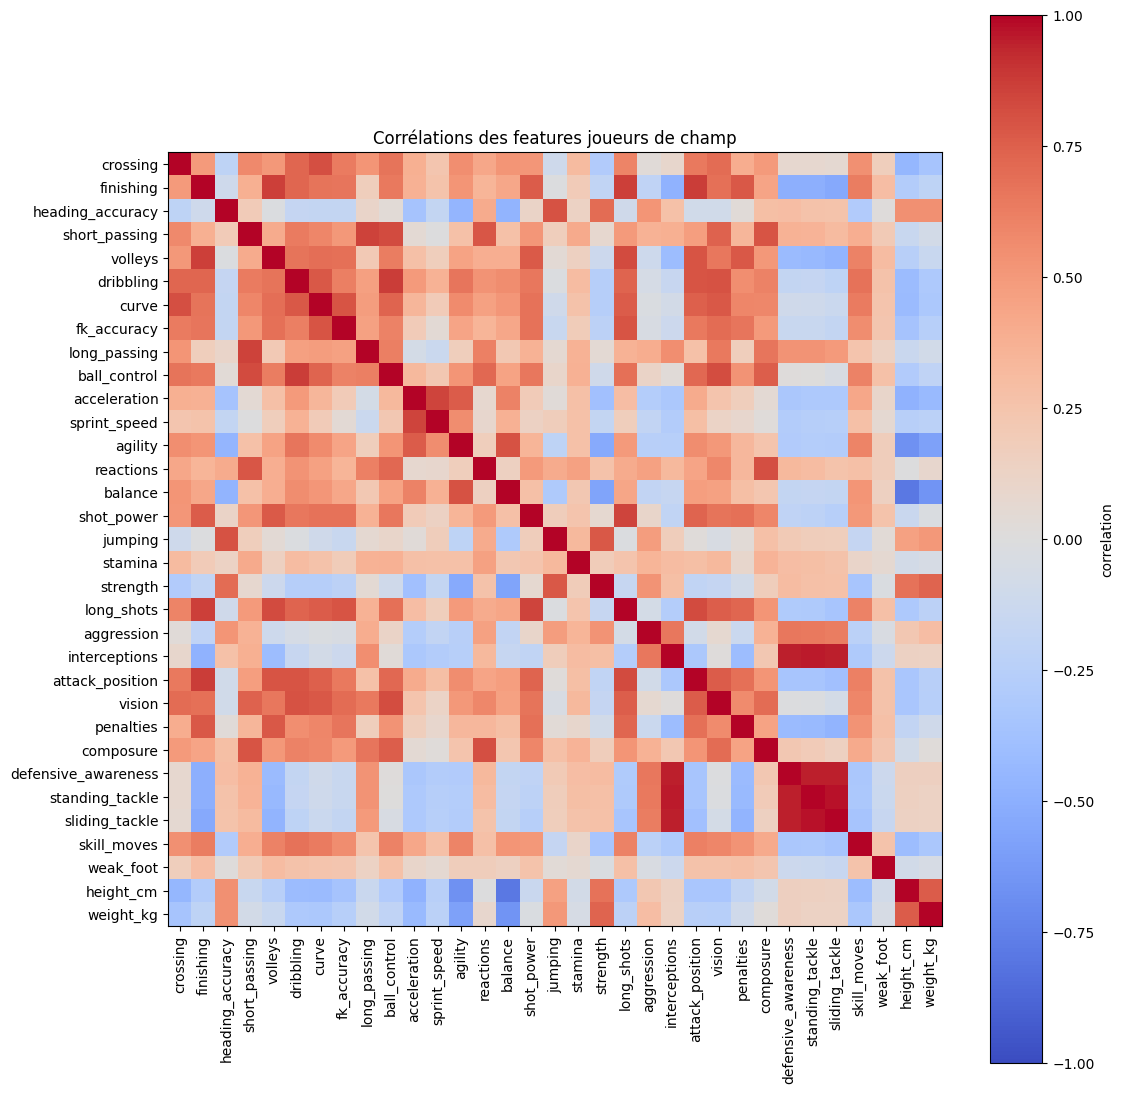

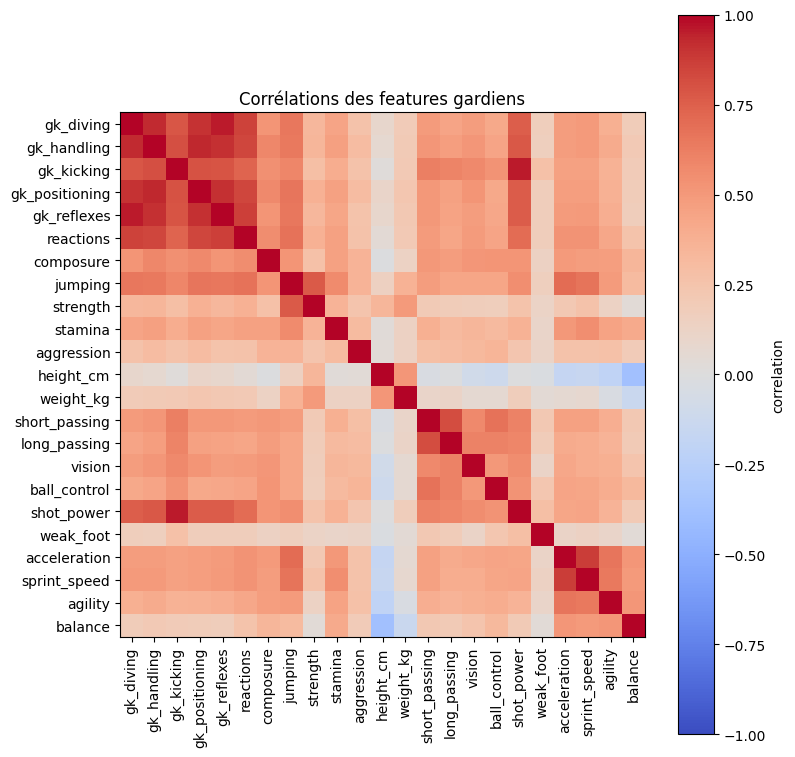

Corrélations agrégats joueurs de champ


,pace,shooting,passing,dribbling,defending,physical
pace,1.00,0.27,0.19,0.48,-0.33,-0.07
shooting,0.27,1.00,0.74,0.71,-0.40,-0.00
passing,0.19,0.74,1.00,0.83,0.06,0.06
dribbling,0.48,0.71,0.83,1.00,-0.08,0.04
defending,-0.33,-0.40,0.06,-0.08,1.00,0.56
physical,-0.07,-0.00,0.06,0.04,0.56,1.00


Corrélations agrégats gardiens


,goalkeeping,keeper_distribution,keeper_mobility,keeper_physical
goalkeeping,1.00,0.61,0.61,0.58
keeper_distribution,0.61,1.00,0.56,0.48
keeper_mobility,0.61,0.56,1.00,0.60
keeper_physical,0.58,0.48,0.60,1.00


Features croisées candidates


,mean,std,min,25%,50%,75%,max
attack_vs_defense,1.9,24.5,-52.2,-17.0,-1.4,26.2,54.6
technique_vs_physical,0.2,11.4,-32.4,-7.9,-0.3,7.6,36.5
passing_vs_shooting,2.9,8.8,-29.2,-1.7,3.8,8.7,30.0
pace_vs_physical,1.6,14.6,-47.5,-7.8,1.5,11.5,44.3
keeper_distribution_vs_goalkeeping,-36.1,7.4,-57.0,-41.4,-36.6,-31.2,-15.6
keeper_mobility_vs_physical,-0.1,7.0,-19.4,-4.8,0.1,4.4,23.5


,player_id,best_position,attack_vs_defense,technique_vs_physical,passing_vs_shooting,pace_vs_physical,keeper_distribution_vs_goalkeeping,keeper_mobility_vs_physical
0,889193,CAM,23.3,20.7,-5.3,29.0,NaN,NaN
1,434207,ST,36.7,2.5,-13.3,7.0,NaN,NaN
2,92571,LB,-14.7,2.7,14.2,-16.5,NaN,NaN
3,591949,RB,-14.8,4.8,6.0,4.5,NaN,NaN
4,123951,CM,5.3,-0.3,3.1,-14.0,NaN,NaN


In [72]:
# Fonction simple pour extraire les paires de features les plus corrélées.
def top_correlated_pairs(frame: pd.DataFrame, columns: list[str], top_n: int = 30) -> pd.DataFrame:
    correlation_df = frame[columns].corr().abs()

    pairs = []
    for i, left_column in enumerate(columns):
        for right_column in columns[i + 1:]:
            pairs.append({
                "feature_1": left_column,
                "feature_2": right_column,
                "abs_correlation": correlation_df.loc[left_column, right_column],
            })

    return (
        pd.DataFrame(pairs)
        .sort_values("abs_correlation", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def plot_correlation_heatmap(frame: pd.DataFrame, columns: list[str], title: str) -> None:
    correlation_df = frame[columns].corr()

    plt.figure(figsize=(max(8, len(columns) * 0.35), max(7, len(columns) * 0.35)))
    plt.imshow(correlation_df, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="correlation")
    plt.xticks(range(len(columns)), columns, rotation=90)
    plt.yticks(range(len(columns)), columns)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# 1. Corrélations raw, séparées entre joueurs de champ et gardiens.
field_top_correlations_df = top_correlated_pairs(
    field_players_df,
    field_attribute_set,
    top_n=30,
)

gk_top_correlations_df = top_correlated_pairs(
    goalkeepers_df,
    goalkeeper_attribute_set,
    top_n=30,
)

print("Top corrélations joueurs de champ")
display(field_top_correlations_df)

print("Top corrélations gardiens")
display(gk_top_correlations_df)

plot_correlation_heatmap(
    field_players_df,
    field_attribute_set,
    "Corrélations des features joueurs de champ",
)

plot_correlation_heatmap(
    goalkeepers_df,
    goalkeeper_attribute_set,
    "Corrélations des features gardiens",
)

# 2. Corrélations entre agrégats, plus lisibles pour raisonner métier.
field_aggregate_correlation_df = players_engineered_df.loc[
    players_engineered_df["best_position"] != "GK",
    field_aggregate_feature_columns,
].corr().round(2)

gk_aggregate_correlation_df = players_engineered_df.loc[
    players_engineered_df["best_position"] == "GK",
    gk_aggregate_feature_columns,
].corr().round(2)

print("Corrélations agrégats joueurs de champ")
display(field_aggregate_correlation_df)

print("Corrélations agrégats gardiens")
display(gk_aggregate_correlation_df)

# 3. Features croisées candidates : écarts entre familles.
# Elles sont simples à lire et peuvent aider à capter un style plutôt qu'un niveau global.
field_cross_features = {
    "attack_vs_defense": ("shooting", "defending"),
    "technique_vs_physical": ("dribbling", "physical"),
    "passing_vs_shooting": ("passing", "shooting"),
    "pace_vs_physical": ("pace", "physical"),
}

gk_cross_features = {
    "keeper_distribution_vs_goalkeeping": ("keeper_distribution", "goalkeeping"),
    "keeper_mobility_vs_physical": ("keeper_mobility", "keeper_physical"),
}

cross_feature_columns = []

for new_column, (left_column, right_column) in field_cross_features.items():
    players_engineered_df[new_column] = None
    mask = players_engineered_df["best_position"] != "GK"
    players_engineered_df.loc[mask, new_column] = (
        players_engineered_df.loc[mask, left_column]
        - players_engineered_df.loc[mask, right_column]
    ).round(1)
    players_engineered_df[new_column] = pd.to_numeric(players_engineered_df[new_column], errors="coerce")
    cross_feature_columns.append(new_column)

for new_column, (left_column, right_column) in gk_cross_features.items():
    players_engineered_df[new_column] = None
    mask = players_engineered_df["best_position"] == "GK"
    players_engineered_df.loc[mask, new_column] = (
        players_engineered_df.loc[mask, left_column]
        - players_engineered_df.loc[mask, right_column]
    ).round(1)
    players_engineered_df[new_column] = pd.to_numeric(players_engineered_df[new_column], errors="coerce")
    cross_feature_columns.append(new_column)

cross_feature_summary_df = (
    players_engineered_df[cross_feature_columns]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(1)
)

print("Features croisées candidates")
display(cross_feature_summary_df)
display(players_engineered_df[["player_id", "best_position"] + cross_feature_columns].head())

## 12. Préparer le clustering par position

In [73]:
MIN_PLAYERS_BY_POSITION = 30

position_ready_summary_df = (
    players_engineered_df
    .groupby(["position_group", "best_position"])
    .agg(player_count=("player_id", "count"))
    .reset_index()
    .sort_values(["position_group", "player_count"], ascending=[True, False])
)

position_ready_summary_df["feature_count"] = position_ready_summary_df["best_position"].map(
    lambda position: len(absolute_features_by_position[position])
)
position_ready_summary_df["ready_for_clustering"] = (
    position_ready_summary_df["player_count"] >= MIN_PLAYERS_BY_POSITION
)

positions_ready_for_clustering = position_ready_summary_df[
    position_ready_summary_df["ready_for_clustering"]
]["best_position"].tolist()

players_by_position = {
    position: players_engineered_df[players_engineered_df["best_position"] == position].copy()
    for position in positions_ready_for_clustering
}

display(position_ready_summary_df)
print("Positions prêtes:", positions_ready_for_clustering)

,position_group,best_position,player_count,feature_count,ready_for_clustering
3,Attaquant,ST,688,33,True
2,Attaquant,RW,78,33,True
1,Attaquant,LW,55,33,True
0,Attaquant,CF,24,33,False
4,Défenseur,CB,995,33,True
7,Défenseur,RB,243,33,True
5,Défenseur,LB,236,33,True
8,Défenseur,RWB,63,33,True
6,Défenseur,LWB,60,33,True
9,Gardien,GK,505,23,True


Positions prêtes: ['ST', 'RW', 'LW', 'CB', 'RB', 'LB', 'RWB', 'LWB', 'GK', 'CAM', 'CM', 'CDM', 'RM', 'LM']


## 13. Prochaine étape

Le notebook est prêt pour un clustering par `best_position`.

Pour chaque position, on pourra comparer :

- `absolute_features_by_position[position]` : features adaptées au poste, avec niveau + style ;
- `relative_features_by_position[position]` : mêmes features mais relatives au niveau moyen du joueur, plus orientées style.

Point important : `GK` utilisera bien `goalkeeper_attribute_set`, tandis que les autres postes utiliseront `field_attribute_set`.